In [1]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset

df = pd.read_csv("employees_dataset.csv")

In [3]:
# Display first few rows

df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
0,8724,Technology,region_26,Bachelors,m,sourcing,1,24,NaN,1,1,0,77
1,74430,HR,region_4,Bachelors,f,other,1,31,3.0,5,0,0,51
2,72255,Sales & Marketing,region_13,Bachelors,m,other,1,31,1.0,4,0,0,47
3,38562,Procurement,region_2,Bachelors,f,other,3,31,2.0,9,0,0,65
4,64486,Finance,region_29,Bachelors,m,sourcing,1,30,4.0,7,0,0,61


### Data Preprocessing

In [4]:
# Check for missing values

df.isnull().sum()

employee_id                 0
department                  0
region                      0
education                 771
gender                      0
recruitment_channel         0
no_of_trainings             0
age                         0
previous_year_rating     1363
length_of_service           0
KPIs_met_more_than_80       0
awards_won                  0
avg_training_score          0
dtype: int64

In [5]:
# Fill missing values: Previous year rating with median

df['previous_year_rating'].fillna(df['previous_year_rating'].median(), inplace=True)

### Exploratory Data Analysis (EDA) 

In [6]:
# Summary statistics

df.describe()

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
count,17417.000000,17417.000000,17417.000000,17417.000000,17417.000000,17417.000000,17417.000000,17417.000000
mean,39083.491129,1.250732,34.807774,3.318425,5.801860,0.358845,0.023368,63.176322
std,22707.024087,0.595692,7.694046,1.218400,4.175533,0.479675,0.151074,13.418179
min,3.000000,1.000000,20.000000,1.000000,1.000000,0.000000,0.000000,39.000000
25%,19281.000000,1.000000,29.000000,3.000000,3.000000,0.000000,0.000000,51.000000
50%,39122.000000,1.000000,33.000000,3.000000,5.000000,0.000000,0.000000,60.000000
75%,58838.000000,1.000000,39.000000,4.000000,7.000000,1.000000,0.000000,75.000000
max,78295.000000,9.000000,60.000000,5.000000,34.000000,1.000000,1.000000,99.000000


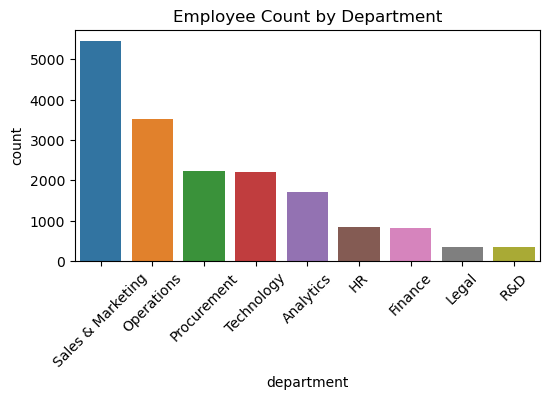

In [7]:
# Count of employees per department

plt.figure(figsize=(6, 3))
sns.countplot(data=df, x="department", order=df["department"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Employee Count by Department")
plt.show()

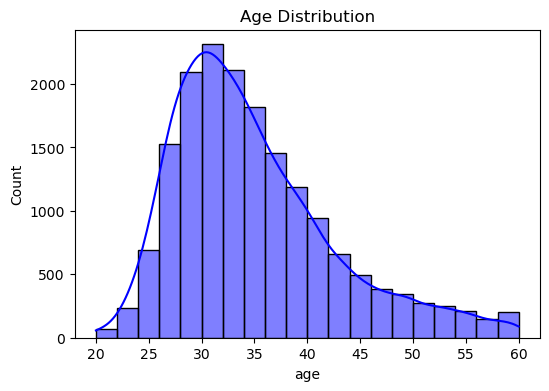

In [9]:
# Distribution of Age

plt.figure(figsize=(6,4))
sns.histplot(df['age'], bins=20, kde=True, color="blue")
plt.title("Age Distribution")
plt.show()

### Key Metrics Analysis

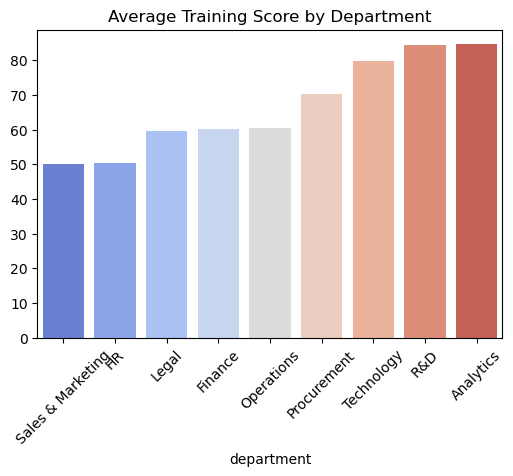

In [10]:
# Average training score per department

dept_training = df.groupby("department")["avg_training_score"].mean().sort_values()
plt.figure(figsize=(6, 4))
sns.barplot(x=dept_training.index, y=dept_training.values, palette="coolwarm")
plt.xticks(rotation=45)
plt.title("Average Training Score by Department")
plt.show()

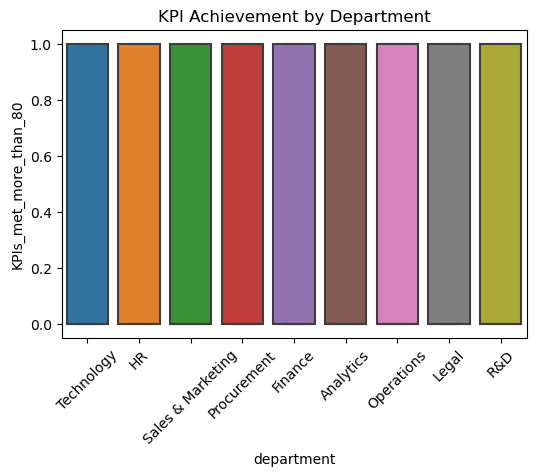

In [11]:
# KPI achievement vs. department

plt.figure(figsize=(6,4))
sns.boxplot(x="department", y="KPIs_met_more_than_80", data=df)
plt.xticks(rotation=45)
plt.title("KPI Achievement by Department")
plt.show()

### Retention Trends Analysis

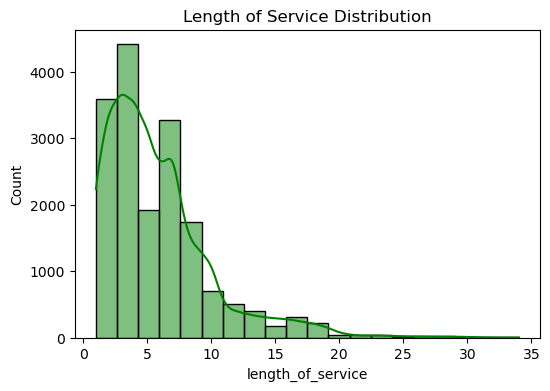

In [12]:
# Length of service distribution

plt.figure(figsize=(6,4))
sns.histplot(df['length_of_service'], bins=20, kde=True, color="green")
plt.title("Length of Service Distribution")
plt.show()

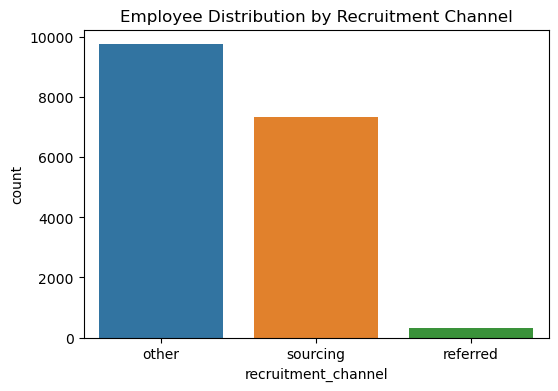

In [13]:
# Employee count by recruitment channel

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="recruitment_channel", order=df["recruitment_channel"].value_counts().index)
plt.title("Employee Distribution by Recruitment Channel")
plt.show()

### HR Recommendations

In [14]:
# High-performing employees: KPI > 80% & high avg training score

high_performers = df[(df["KPIs_met_more_than_80"] == 1) & (df["avg_training_score"] > df["avg_training_score"].median())]
print("High Performing Employees by Department:\n", high_performers["department"].value_counts())

High Performing Employees by Department:
 Procurement          836
Technology           783
Analytics            679
Operations           565
R&D                  149
Finance              115
Sales & Marketing     45
Legal                 37
HR                    11
Name: department, dtype: int64


In [15]:
# Retention Concern: Employees with long service but low KPI & training scores
low_performers = df[(df["length_of_service"] > df["length_of_service"].median()) & 
                    (df["KPIs_met_more_than_80"] == 0) & 
                    (df["avg_training_score"] < df["avg_training_score"].median())]
print("Employees at Retention Risk by Department:\n", low_performers["department"].value_counts())

print("\nBusiness insights generated successfully!")


Employees at Retention Risk by Department:
 Sales & Marketing    1725
Operations            455
HR                    222
Finance                88
Legal                  37
Name: department, dtype: int64

Business insights generated successfully!
